# EDA — Registro histórico de incendios forestales CONAF

Análisis exploratorio del registro histórico de incendios forestales identificados por CONAF entre las temporadas 2002-2003 y 2019-2020.

**Objetivo**: caracterizar eventos, alertas, escenarios, distribución temporal/espacial, duración y superficie quemada para informar el modelado posterior. Este notebook usa solo datos CONAF limpios mediante `load_conaf()`; no incorpora ERA5 ni datasets enriquecidos.

## Fuente y variables

Fuente pública: [Datos para Resiliencia / itrend](https://datospararesiliencia.cl/dataset.xhtml?persistentId=doi:10.71578/UXAUN5), DOI `10.71578/UXAUN5`.

El registro incluye, por evento:

- **Ubicación**: región, provincia, comuna, latitud, longitud y datum del punto de ignición estimado.
- **Fecha**: temporada, fecha, hora de inicio y duración en minutos.
- **Información del evento**: nombre, alerta emitida, escenario y causa.
- **Superficie quemada**: desglose por pino A/B/C, eucalipto, otras plantas, arbolado, matorral, pastizal, agrícola, desechos y total en hectáreas.

## Glosario de escenarios

- `IFor-PI`: incendio forestal de plantaciones; afecta principalmente plantaciones forestales y desechos de manejo forestal.
- `IFor-Vn`: incendio forestal de vegetación natural; afecta bosque adulto, renovales, matorrales, desechos nativos y eventualmente suelos agrícolas.
- `IFIUr-Fo`: incendio forestal de interfaz urbano forestal; amenaza o afecta vegetación y áreas pobladas, industriales o infraestructura productiva. En la descripción original puede aparecer como `FIUr-Fo`.
- `IFCo`: incendio forestal cordillerano; ocurre sobre 1.000 m.s.n.m. con acceso terrestre y operación aérea complejos.
- `IFSu`: incendio forestal subterráneo; propagación incandescente bajo suelo tras extinción superficial.
- `IFCSo`: incendio forestal de conflicto social; ocurre en territorios definidos como zonas de conflicto social/territorial.
- `IFASP`: incendio forestal en Área Silvestre Protegida del SNASPE.
- `IFIns`: incendio forestal insular; ocurre en islas o archipiélagos de acceso marítimo o aéreo.
- `No definido`: registros sin escenario específico informado.

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/xai-project-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

cwd = Path.cwd()
ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(ROOT) not in sys.path:
	sys.path.insert(0, str(ROOT))

import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from src.conaf_loader import load_conaf

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10

SUP_TOTAL = "superficie_quemada_total_ha"
VEG_COLS = [
	"superficie_quemada_pino_a_ha",
	"superficie_quemada_pino_b_ha",
	"superficie_quemada_pino_c_ha",
	"superficie_quemada_eucalipto_ha",
	"superficie_quemada_otras_plantas_ha",
	"superficie_quemada_arbolado_ha",
	"superficie_quemada_matorral_ha",
	"superficie_quemada_pastizal_ha",
	"superficie_quemada_agricola_ha",
	"superficie_quemada_desechos_ha",
]

def fmt_int(value):
	return f"{int(value):,}".replace(",", ".")

def fmt_ha(value):
	return f"{float(value):,.1f}".replace(",", "X").replace(".", ",").replace("X", ".")

def pct(value):
	return f"{100 * float(value):.1f}%".replace(".", ",")

## 2. Carga y visión general

In [2]:
gdf = load_conaf()
df = pd.DataFrame(gdf.drop(columns="geometry", errors="ignore")).copy()

required = {
	"region",
	"provincia",
	"comuna",
	"temporada",
	"fecha_hora_inicio",
	"duracion_minutos",
	"alerta",
	"escenario",
	"causa",
	SUP_TOTAL,
	"latitud",
	"longitud",
}
missing_required = sorted(required - set(df.columns))
if missing_required:
	raise KeyError(f"Faltan columnas requeridas: {missing_required}")

df["fecha_hora_inicio"] = pd.to_datetime(df["fecha_hora_inicio"], errors="coerce")
df["fecha_hora_inicio_utc"] = pd.to_datetime(df["fecha_hora_inicio_utc"], errors="coerce")
df["superficie_total_ha"] = pd.to_numeric(df[SUP_TOTAL], errors="coerce")
df["duracion_horas"] = pd.to_numeric(df["duracion_minutos"], errors="coerce") / 60
df["anio"] = df["fecha_hora_inicio"].dt.year
df["mes"] = df["fecha_hora_inicio"].dt.month
day_names = {0: "lunes", 1: "martes", 2: "miércoles", 3: "jueves", 4: "viernes", 5: "sábado", 6: "domingo"}
df["dia_semana"] = df["fecha_hora_inicio"].dt.dayofweek.map(day_names)
df["hora"] = df["fecha_hora_inicio"].dt.hour

overview = pd.DataFrame(
	{
		"métrica": [
			"Registros",
			"Columnas",
			"Temporadas",
			"Rango temporal local",
			"Superficie total quemada (ha)",
			"Mediana por evento (ha)",
		],
		"valor": [
			fmt_int(len(df)),
			fmt_int(df.shape[1]),
			f"{df['temporada'].min()} a {df['temporada'].max()} ({df['temporada'].nunique()} temporadas)",
			f"{df['fecha_hora_inicio'].min()} a {df['fecha_hora_inicio'].max()}",
			fmt_ha(df["superficie_total_ha"].sum()),
			fmt_ha(df["superficie_total_ha"].median()),
		],
	}
)
display(overview)
display(df.head(3))

INFO: Cargando cache limpio: /home/imorales/Desktop/XAI/XAI-project/data/interim/conaf_clean.parquet


,métrica,valor
0,Registros,109.947
1,Columnas,33
2,Temporadas,2002-2003 a 2019-2020 (18 temporadas)
3,Rango temporal local,2002-07-01 14:00:00 a 2020-06-21 20:59:00
4,Superficie total quemada (ha),"1.562.870,0"
5,Mediana por evento (ha),"0,3"


,region,provincia,comuna,temporada,nombre,fecha,hora_inicio,duracion_minutos,alerta,escenario,causa,superficie_quemada_pino_a_ha,superficie_quemada_pino_b_ha,superficie_quemada_pino_c_ha,superficie_quemada_eucalipto_ha,superficie_quemada_otras_plantas_ha,superficie_quemada_arbolado_ha,superficie_quemada_matorral_ha,superficie_quemada_pastizal_ha,superficie_quemada_agricola_ha,superficie_quemada_desechos_ha,superficie_quemada_total_ha,latitud,longitud,datum,fecha_hora_inicio,fecha_hora_inicio_utc,superficie_total_ha,duracion_horas,anio,mes,dia_semana,hora
0,Coquimbo,Elqui,La Serena,2002-2003,ALTOVALSOL,2002-07-05,21:05,195.00,Sin alerta,No definido,No definida,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.00,0.00,0.04,-29.94,-71.11,WGS84,2002-07-05 21:05:00,2002-07-06 01:05:00,0.04,3.25,2002,7,viernes,21
1,Coquimbo,Elqui,La Serena,2002-2003,CERES,2002-10-25,11:50,137.00,Sin alerta,No definido,No definida,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.02,-29.93,-71.21,WGS84,2002-10-25 11:50:00,2002-10-25 14:50:00,0.02,2.28,2002,10,viernes,11
2,Coquimbo,Limarí,Punitaqui,2002-2003,LA RINCONADA,2002-10-27,11:50,190.00,Sin alerta,No definido,No definida,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.01,-30.83,-71.37,WGS84,2002-10-27 11:50:00,2002-10-27 14:50:00,0.01,3.17,2002,10,domingo,11


In [3]:
dtypes = (
	df.dtypes.astype(str)
	.rename("dtype")
	.reset_index()
	.rename(columns={"index": "columna"})
)
display(dtypes)

,columna,dtype
0,region,str
1,provincia,str
2,comuna,str
3,temporada,str
4,nombre,str
5,fecha,datetime64[us]
6,hora_inicio,str
7,duracion_minutos,float64
8,alerta,str
9,escenario,str


## 3. Calidad de datos

In [4]:
lat = pd.to_numeric(df["latitud"], errors="coerce")
lon = pd.to_numeric(df["longitud"], errors="coerce")
sup = df["superficie_total_ha"]
duration = pd.to_numeric(df["duracion_minutos"], errors="coerce")
chile_bbox = lat.between(-56, -17) & lon.between(-76, -66)

quality = pd.DataFrame(
	{
		"chequeo": [
			"Duplicados exactos",
			"Timestamp local nulo",
			"Timestamp UTC derivado nulo",
			"Sin coordenadas",
			"Fuera de bbox continental amplio",
			"Superficie total nula",
			"Superficie total negativa",
			"Superficie total cero",
			"Duración nula",
			"Duración negativa",
		],
		"registros": [
			int(df.duplicated().sum()),
			int(df["fecha_hora_inicio"].isna().sum()),
			int(df["fecha_hora_inicio_utc"].isna().sum()),
			int((lat.isna() | lon.isna()).sum()),
			int((~chile_bbox & lat.notna() & lon.notna()).sum()),
			int(sup.isna().sum()),
			int((sup < 0).sum()),
			int((sup == 0).sum()),
			int(duration.isna().sum()),
			int((duration < 0).sum()),
		],
	}
)
quality["porcentaje"] = quality["registros"] / len(df)
display(quality.style.format({"registros": "{:,}", "porcentaje": "{:.2%}"}))

,chequeo,registros,porcentaje
0,Duplicados exactos,0,0.00%
1,Timestamp local nulo,0,0.00%
2,Timestamp UTC derivado nulo,6,0.01%
3,Sin coordenadas,0,0.00%
4,Fuera de bbox continental amplio,209,0.19%
5,Superficie total nula,0,0.00%
6,Superficie total negativa,0,0.00%
7,Superficie total cero,170,0.15%
8,Duración nula,0,0.00%
9,Duración negativa,"1,338",1.22%


,columna,proporcion_nula,nulos
0,fecha_hora_inicio_utc,0.01%,6
1,region,0.00%,0
2,provincia,0.00%,0
3,temporada,0.00%,0
4,comuna,0.00%,0
5,fecha,0.00%,0
6,hora_inicio,0.00%,0
7,duracion_minutos,0.00%,0
8,nombre,0.00%,0
9,escenario,0.00%,0


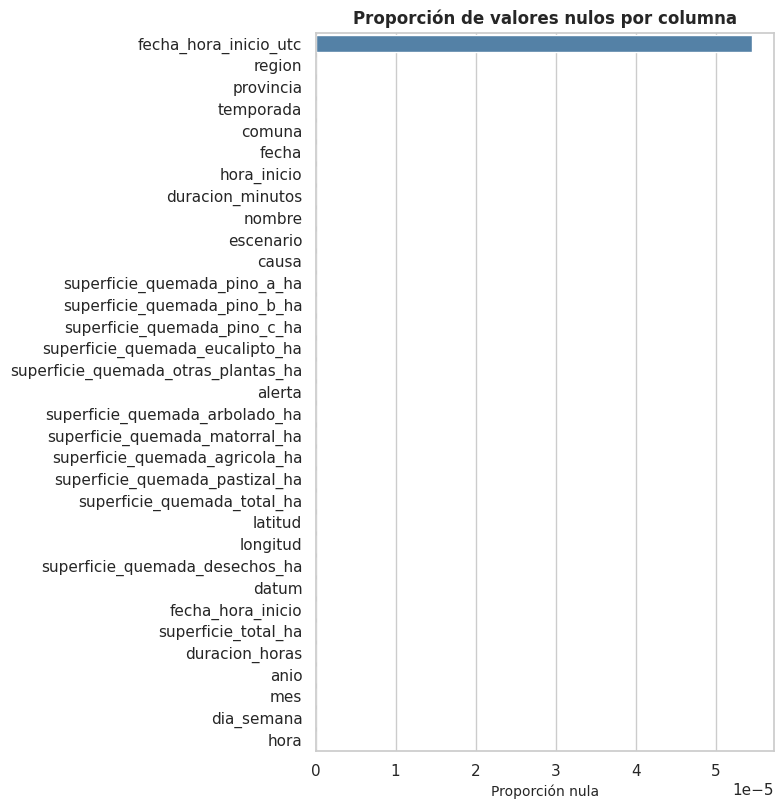

In [5]:
missing = (
	df.isna()
	.mean()
	.sort_values(ascending=False)
	.rename("proporcion_nula")
	.reset_index()
	.rename(columns={"index": "columna"})
)
missing["nulos"] = (missing["proporcion_nula"] * len(df)).round().astype(int)
display(missing.head(15).style.format({"proporcion_nula": "{:.2%}", "nulos": "{:,}"}))

plt.figure(figsize=(8, max(4, len(missing) * 0.25)))
sns.barplot(data=missing, x="proporcion_nula", y="columna", color="steelblue")
plt.title("Proporción de valores nulos por columna")
plt.xlabel("Proporción nula")
plt.ylabel("")
plt.tight_layout()

## 4. Resumen por temporada

In [6]:
alert_types = (
	df.groupby("temporada")["alerta"]
	.apply(lambda s: ", ".join(f"{name} ({fmt_int(count)})" for name, count in s.value_counts().items()))
	.rename("alertas_emitidas")
)

season_summary = (
	df.groupby("temporada")
	.agg(
		eventos=("temporada", "size"),
		superficie_total_ha=("superficie_total_ha", "sum"),
		superficie_mediana_ha=("superficie_total_ha", "median"),
		duracion_mediana_min=("duracion_minutos", "median"),
		regiones=("region", "nunique"),
		comunas=("comuna", "nunique"),
	)
	.join(alert_types)
)
season_summary["ha_por_evento"] = season_summary["superficie_total_ha"] / season_summary["eventos"]
display(
	season_summary[
		[
			"eventos",
			"alertas_emitidas",
			"superficie_total_ha",
			"ha_por_evento",
			"superficie_mediana_ha",
			"duracion_mediana_min",
			"regiones",
			"comunas",
		]
	].style.format(
		{
			"eventos": "{:,}",
			"superficie_total_ha": "{:,.1f}",
			"ha_por_evento": "{:,.2f}",
			"superficie_mediana_ha": "{:,.2f}",
			"duracion_mediana_min": "{:,.0f}",
			"regiones": "{:,}",
			"comunas": "{:,}",
		}
	)
)

,eventos,alertas_emitidas,superficie_total_ha,ha_por_evento,superficie_mediana_ha,duracion_mediana_min,regiones,comunas
temporada,,,,,,,,
2002-2003,"7,394",Sin alerta (7.394),"41,531.4",5.62,0.20,91,10,235
2003-2004,"6,164",Sin alerta (6.164),"49,182.1",7.98,0.30,121,11,232
2004-2005,"6,411",Sin alerta (6.411),"61,569.6",9.60,0.30,123,11,228
2005-2006,"5,173",Sin alerta (5.173),"16,674.1",3.22,0.20,111,11,235
2006-2007,"4,986",Sin alerta (4.986),"40,200.3",8.06,0.20,95,9,232
2007-2008,"6,528",Sin alerta (6.528),"35,238.5",5.40,0.30,130,10,234
2008-2009,"5,913",Sin alerta (5.913),"54,687.0",9.25,0.30,135,10,229
2009-2010,"4,067",Sin alerta (4.067),"56,095.3",13.79,0.30,120,11,226
2010-2011,"4,922",Sin alerta (4.922),"39,832.7",8.09,0.30,112,11,245


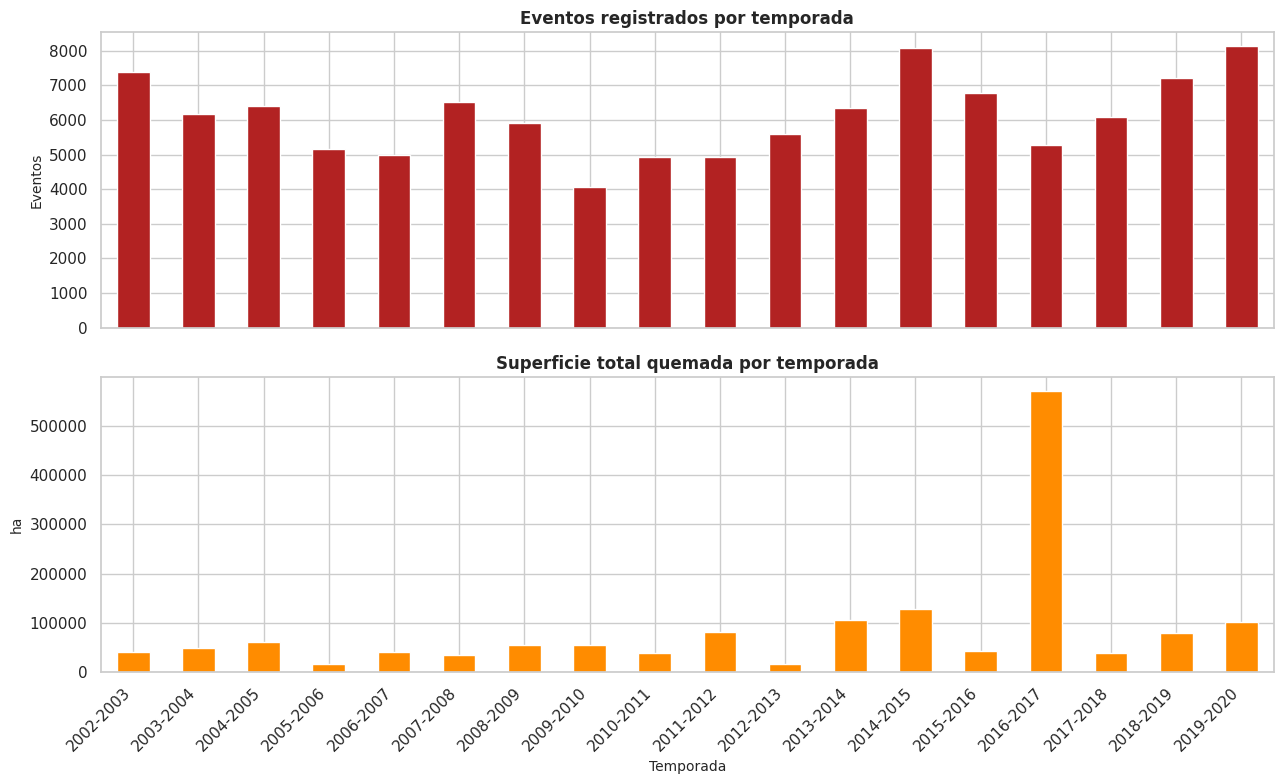

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
season_summary["eventos"].plot(kind="bar", ax=axes[0], color="firebrick")
axes[0].set_title("Eventos registrados por temporada")
axes[0].set_ylabel("Eventos")
season_summary["superficie_total_ha"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Superficie total quemada por temporada")
axes[1].set_ylabel("ha")
axes[1].set_xlabel("Temporada")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

alerta,Alerta amarilla,Alerta roja,Sin alerta
temporada,,,
2002-2003,0,0,"7,394"
2003-2004,0,0,"6,164"
2004-2005,0,0,"6,411"
2005-2006,0,0,"5,173"
2006-2007,0,0,"4,986"
2007-2008,0,0,"6,528"
2008-2009,0,0,"5,913"
2009-2010,0,0,"4,067"
2010-2011,0,0,"4,922"


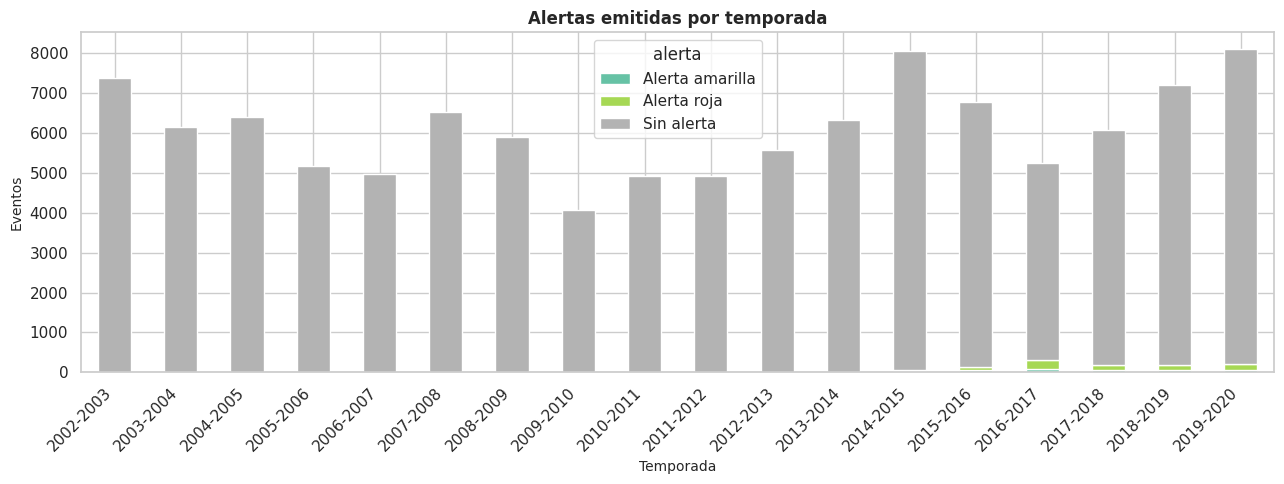

In [8]:
alert_by_season = pd.crosstab(df["temporada"], df["alerta"]).reindex(season_summary.index)
display(alert_by_season.style.format("{:,}"))

alert_by_season.plot(kind="bar", stacked=True, figsize=(13, 5), colormap="Set2")
plt.title("Alertas emitidas por temporada")
plt.xlabel("Temporada")
plt.ylabel("Eventos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## 5. Distribución temporal

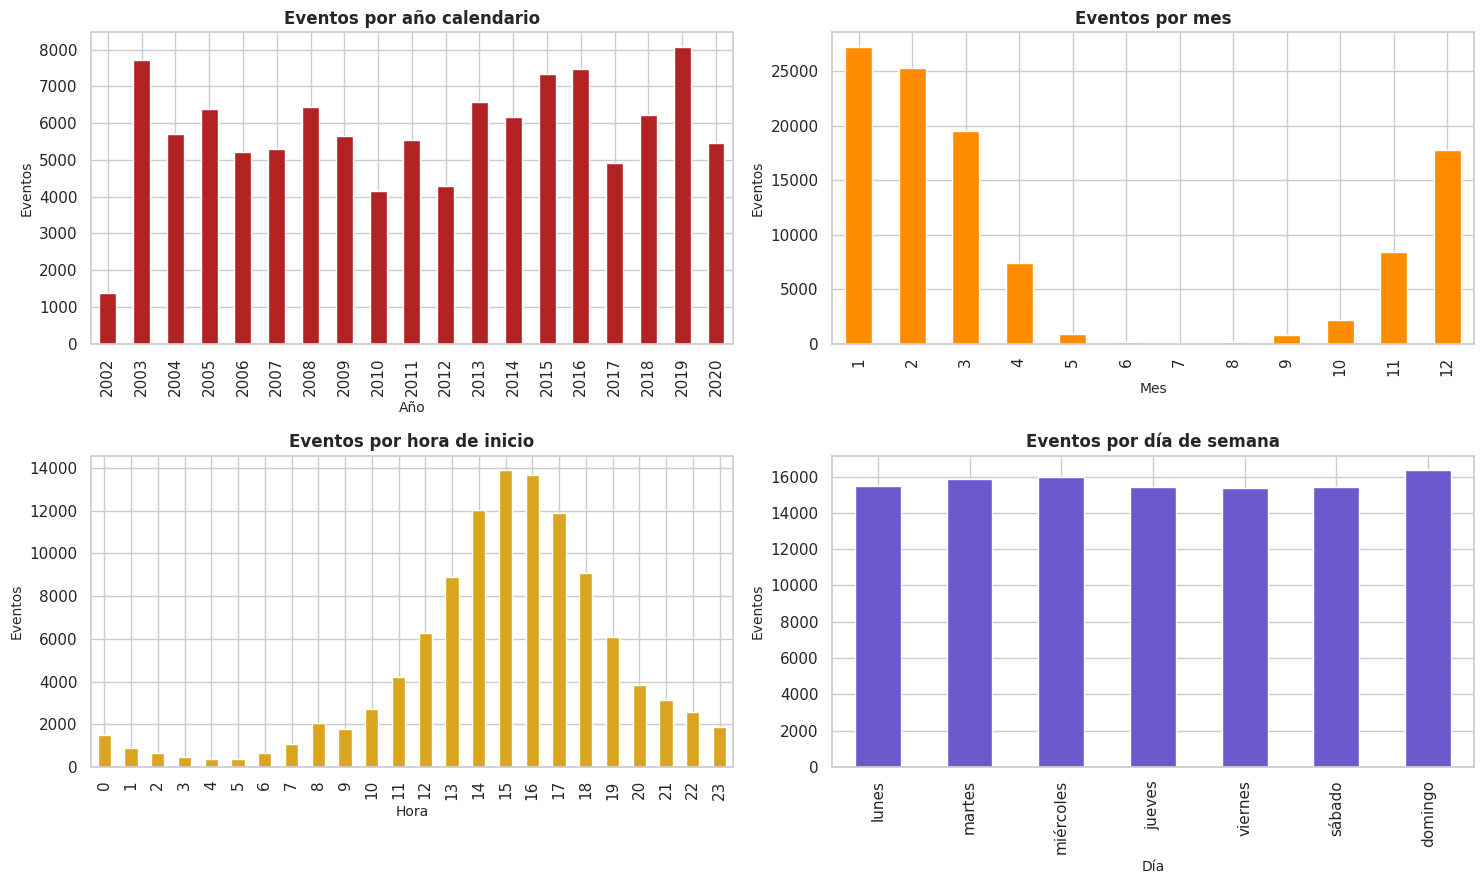

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

df["anio"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="firebrick")
axes[0, 0].set_title("Eventos por año calendario")
axes[0, 0].set_xlabel("Año")
axes[0, 0].set_ylabel("Eventos")

df["mes"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Eventos por mes")
axes[0, 1].set_xlabel("Mes")
axes[0, 1].set_ylabel("Eventos")

df["hora"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 0], color="goldenrod")
axes[1, 0].set_title("Eventos por hora de inicio")
axes[1, 0].set_xlabel("Hora")
axes[1, 0].set_ylabel("Eventos")

weekday_order = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
weekday_counts = df["dia_semana"].value_counts().reindex(weekday_order)
weekday_counts.plot(kind="bar", ax=axes[1, 1], color="slateblue")
axes[1, 1].set_title("Eventos por día de semana")
axes[1, 1].set_xlabel("Día")
axes[1, 1].set_ylabel("Eventos")

plt.tight_layout()

In [10]:
month_summary = (
	df.groupby("mes")
	.agg(eventos=("mes", "size"), superficie_total_ha=("superficie_total_ha", "sum"))
	.assign(pct_eventos=lambda x: x["eventos"] / x["eventos"].sum())
)
display(month_summary.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "pct_eventos": "{:.1%}"}))

,eventos,superficie_total_ha,pct_eventos
mes,,,
1,"27,199","825,444.5",24.7%
2,"25,287","299,486.3",23.0%
3,"19,476","134,459.7",17.7%
4,"7,455","32,728.7",6.8%
5,900,"6,474.8",0.8%
6,177,"1,334.0",0.2%
7,96,650.1,0.1%
8,194,994.3,0.2%
9,793,"4,969.5",0.7%


## 6. Distribución espacial

,eventos,superficie_total_ha,superficie_mediana_ha,comunas
region,,,,
Biobío,"45,720","356,640.3",0.16,54
Araucanía,"19,689","214,572.2",0.50,32
Valparaíso,"14,861","140,101.3",0.30,38
Maule,"10,111","386,081.4",0.71,30
Metropolitana,"8,197","136,195.9",0.50,40
O'Higgins,"4,366","224,185.3",1.00,33
Los Lagos,"2,908","20,860.3",0.48,30
Los Ríos,"1,816","6,244.7",0.50,12
Coquimbo,"1,151","14,933.3",1.00,15


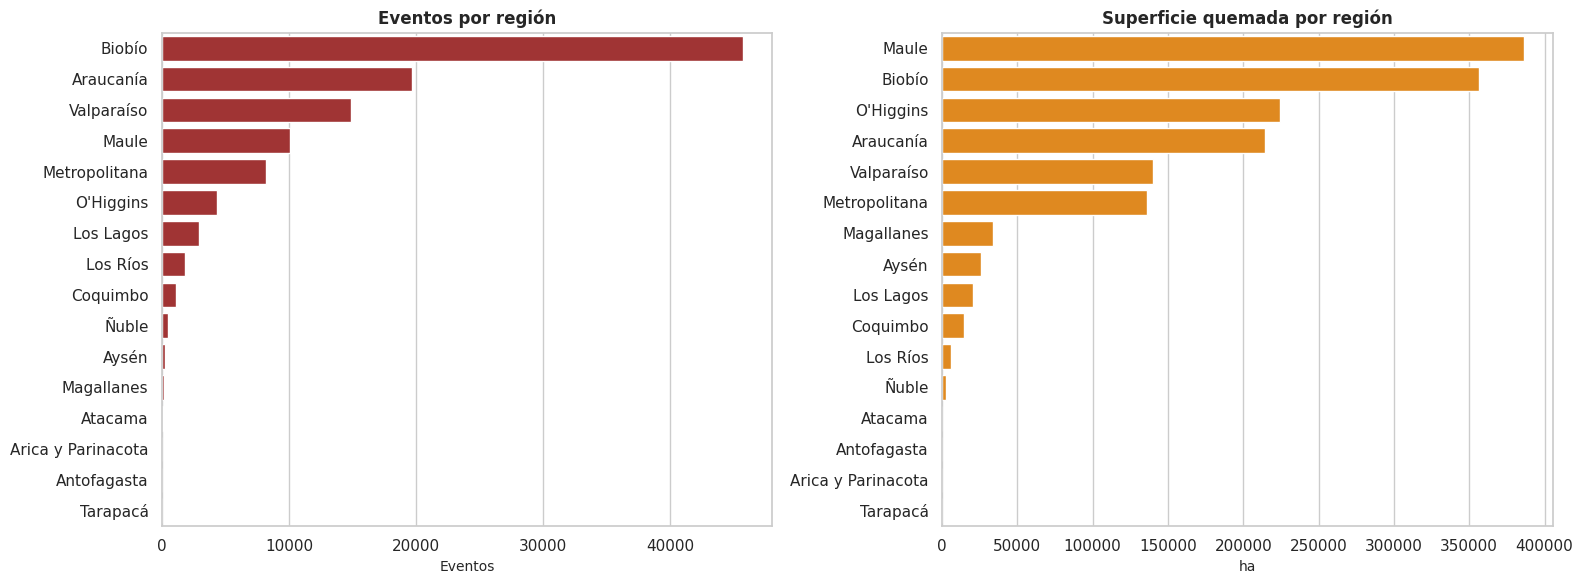

In [11]:
region_summary = (
	df.groupby("region")
	.agg(
		eventos=("region", "size"),
		superficie_total_ha=("superficie_total_ha", "sum"),
		superficie_mediana_ha=("superficie_total_ha", "median"),
		comunas=("comuna", "nunique"),
	)
	.sort_values("eventos", ascending=False)
)
display(region_summary.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "superficie_mediana_ha": "{:,.2f}", "comunas": "{:,}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=region_summary.reset_index(), x="eventos", y="region", ax=axes[0], color="firebrick")
axes[0].set_title("Eventos por región")
axes[0].set_xlabel("Eventos")
axes[0].set_ylabel("")
sns.barplot(data=region_summary.sort_values("superficie_total_ha", ascending=False).reset_index(), x="superficie_total_ha", y="region", ax=axes[1], color="darkorange")
axes[1].set_title("Superficie quemada por región")
axes[1].set_xlabel("ha")
axes[1].set_ylabel("")
plt.tight_layout()

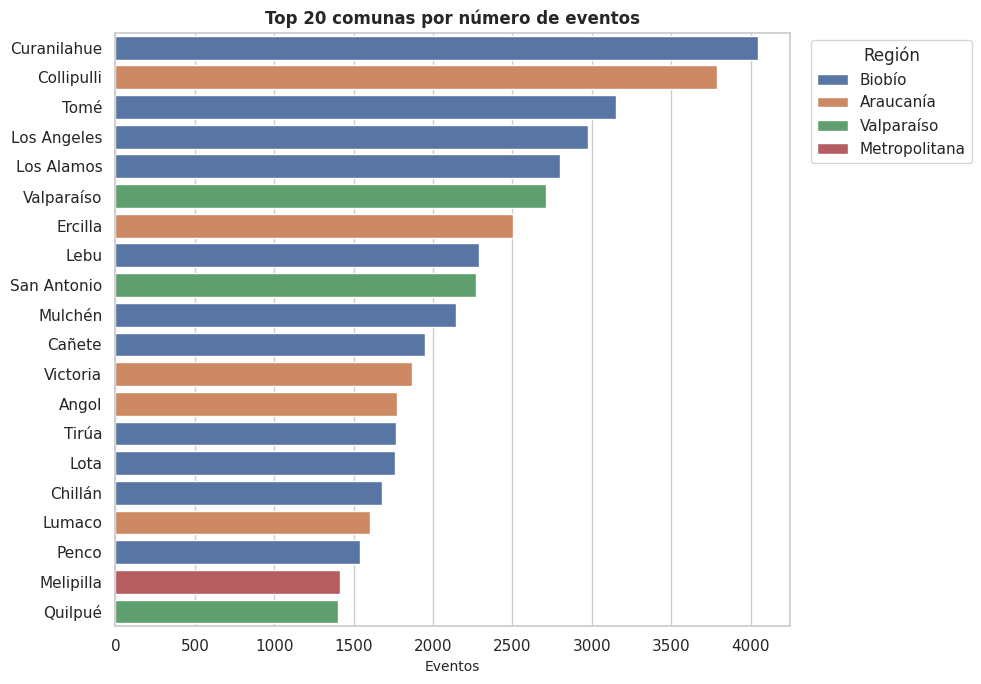

In [12]:
commune_summary = (
	df.groupby(["region", "provincia", "comuna"])
	.agg(eventos=("comuna", "size"), superficie_total_ha=("superficie_total_ha", "sum"))
	.sort_values("eventos", ascending=False)
)
display(commune_summary.head(20).style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}"}))

top_communes = commune_summary.head(20).reset_index()
plt.figure(figsize=(10, 7))
sns.barplot(data=top_communes, x="eventos", y="comuna", hue="region", dodge=False)
plt.title("Top 20 comunas por número de eventos")
plt.xlabel("Eventos")
plt.ylabel("")
plt.legend(title="Región", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

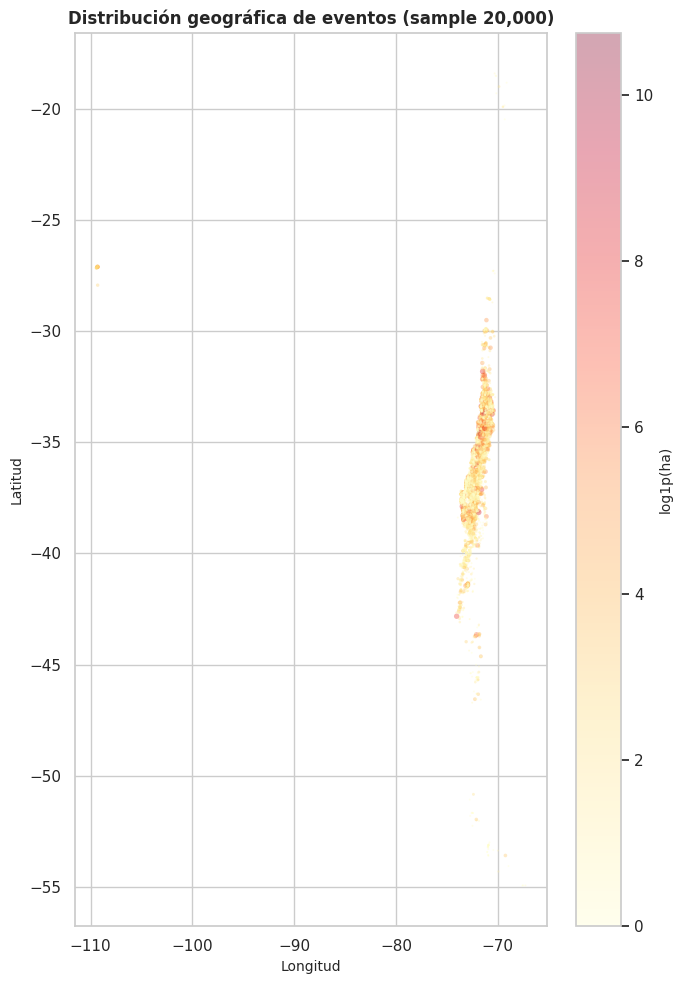

In [13]:
geo = df[["latitud", "longitud", "superficie_total_ha"]].dropna()
geo_sample = geo.sample(min(20_000, len(geo)), random_state=42)

plt.figure(figsize=(7, 10))
plt.scatter(
	geo_sample["longitud"],
	geo_sample["latitud"],
	s=np.clip(np.log1p(geo_sample["superficie_total_ha"]) * 2, 2, 30),
	c=np.log1p(geo_sample["superficie_total_ha"]),
	cmap="YlOrRd",
	alpha=0.35,
	linewidths=0,
)
plt.colorbar(label="log1p(ha)")
plt.title(f"Distribución geográfica de eventos (sample {len(geo_sample):,})")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()

## 7. Alertas, escenarios y causas

In [14]:
def categorical_summary(column):
	return (
		df.groupby(column)
		.agg(eventos=(column, "size"), superficie_total_ha=("superficie_total_ha", "sum"), superficie_mediana_ha=("superficie_total_ha", "median"))
		.assign(pct_eventos=lambda x: x["eventos"] / len(df))
		.sort_values("eventos", ascending=False)
	)

alert_summary = categorical_summary("alerta")
scenario_summary = categorical_summary("escenario")
cause_summary = categorical_summary("causa")

display(alert_summary.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "superficie_mediana_ha": "{:,.2f}", "pct_eventos": "{:.1%}"}))
display(scenario_summary.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "superficie_mediana_ha": "{:,.2f}", "pct_eventos": "{:.1%}"}))

,eventos,superficie_total_ha,superficie_mediana_ha,pct_eventos
alerta,,,,
Sin alerta,"108,873","1,007,024.4",0.30,99.0%
Alerta roja,726,"521,012.7",25.30,0.7%
Alerta amarilla,348,"34,832.9",13.49,0.3%


,eventos,superficie_total_ha,superficie_mediana_ha,pct_eventos
escenario,,,,
No definido,"86,387","767,005.2",0.27,78.6%
IFor-Vn,"12,336","230,805.1",0.60,11.2%
IFIUr-Fo,"7,265","104,917.1",0.33,6.6%
IFor-PI,"3,225","441,030.1",1.20,2.9%
IFCo,284,"9,260.9",1.58,0.3%
IFCSo,244,"5,459.1",1.92,0.2%
IFIns,91,"1,475.3",5.00,0.1%
IFASP,68,"2,791.6",0.23,0.1%
IFSu,47,125.5,0.50,0.0%


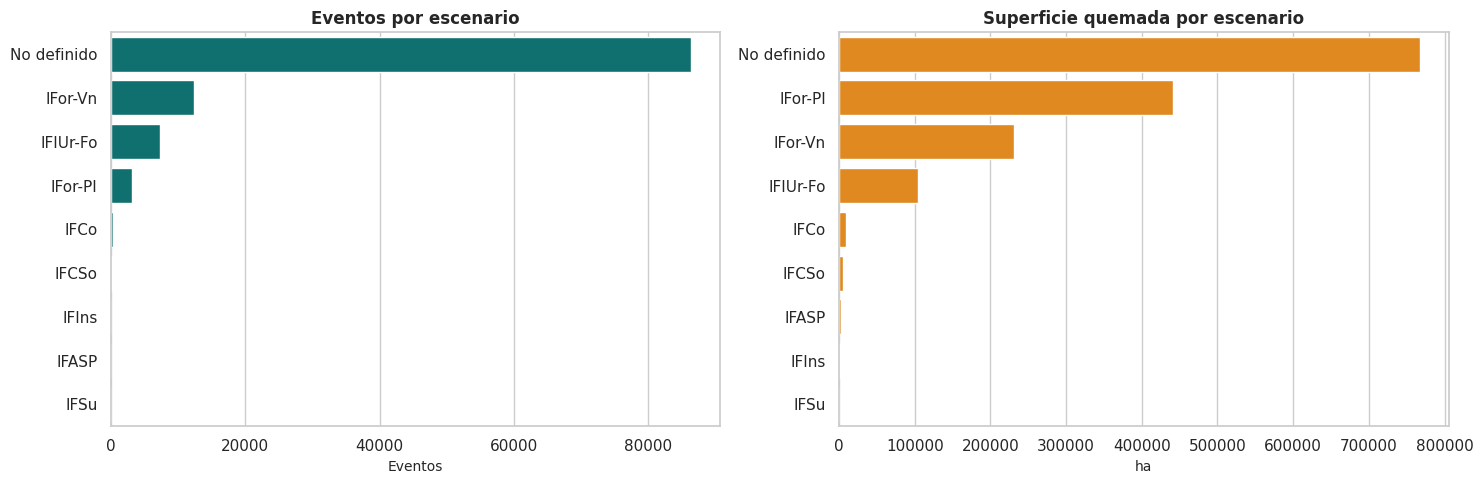

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=scenario_summary.reset_index(), x="eventos", y="escenario", ax=axes[0], color="teal")
axes[0].set_title("Eventos por escenario")
axes[0].set_xlabel("Eventos")
axes[0].set_ylabel("")
sns.barplot(data=scenario_summary.sort_values("superficie_total_ha", ascending=False).reset_index(), x="superficie_total_ha", y="escenario", ax=axes[1], color="darkorange")
axes[1].set_title("Superficie quemada por escenario")
axes[1].set_xlabel("ha")
axes[1].set_ylabel("")
plt.tight_layout()

,eventos,superficie_total_ha,superficie_mediana_ha,pct_eventos
causa,,,,
Incendios intencionales,"36,117","463,117.8",0.18,32.8%
Tránsito de personasvehículos o aeronaves,"32,889","275,274.7",0.40,29.9%
Incendios de causa desconocida,"9,918","292,445.3",0.32,9.0%
Actividades recreativas,"7,108","68,206.0",0.30,6.5%
Faenas agrícolas y pecuarias,"4,638","80,213.0",1.00,4.2%
Faenas forestales,"4,492","30,184.8",0.50,4.1%
Quema de desechos,"4,313","40,830.5",0.40,3.9%
No definida,"3,711","35,935.5",0.15,3.4%
Accidentes eléctricos,"2,520","167,328.8",0.53,2.3%


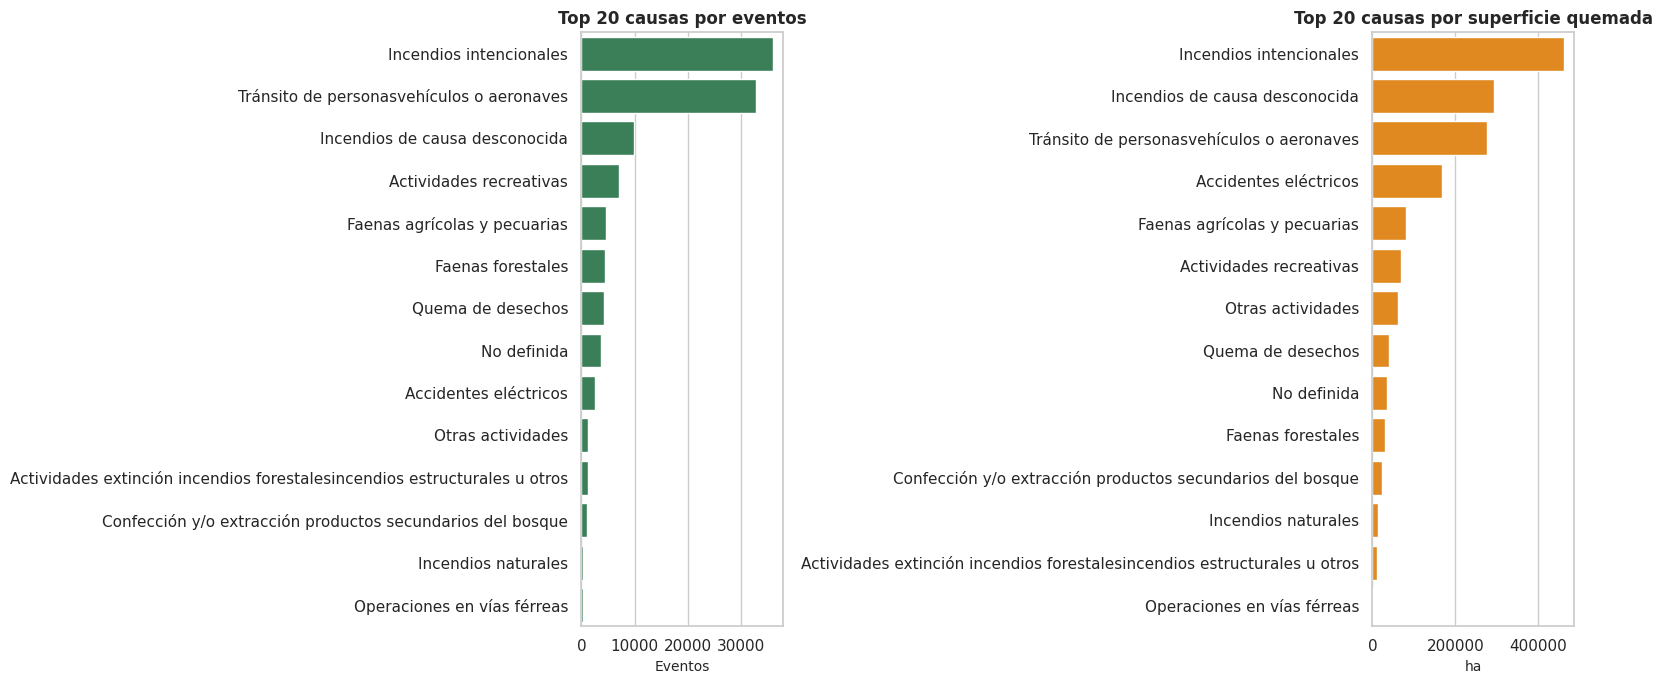

In [16]:
top_causes_events = cause_summary.head(20)
top_causes_surface = cause_summary.sort_values("superficie_total_ha", ascending=False).head(20)

display(top_causes_events.style.format({"eventos": "{:,}", "superficie_total_ha": "{:,.1f}", "superficie_mediana_ha": "{:,.2f}", "pct_eventos": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=top_causes_events.reset_index(), x="eventos", y="causa", ax=axes[0], color="seagreen")
axes[0].set_title("Top 20 causas por eventos")
axes[0].set_xlabel("Eventos")
axes[0].set_ylabel("")
sns.barplot(data=top_causes_surface.reset_index(), x="superficie_total_ha", y="causa", ax=axes[1], color="darkorange")
axes[1].set_title("Top 20 causas por superficie quemada")
axes[1].set_xlabel("ha")
axes[1].set_ylabel("")
plt.tight_layout()

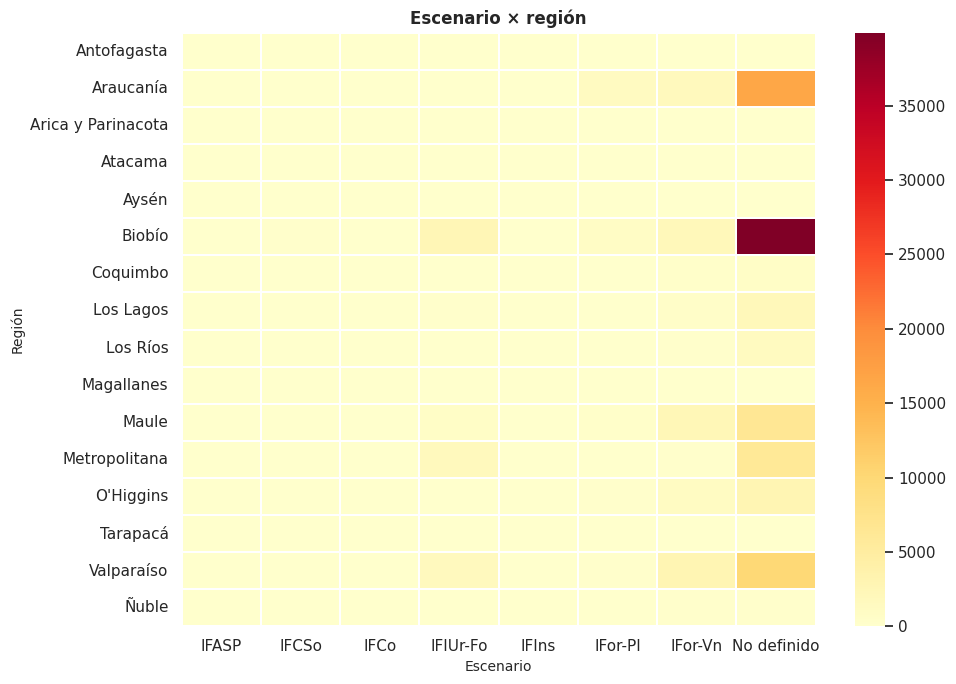

In [17]:
top_scenarios = scenario_summary.head(8).index
scenario_region = pd.crosstab(
	df.loc[df["escenario"].isin(top_scenarios), "region"],
	df.loc[df["escenario"].isin(top_scenarios), "escenario"],
)
plt.figure(figsize=(10, 7))
sns.heatmap(scenario_region, cmap="YlOrRd", linewidths=0.2)
plt.title("Escenario × región")
plt.xlabel("Escenario")
plt.ylabel("Región")
plt.tight_layout()

## 8. Superficie quemada

,superficie_total_ha
count,"109,777.00"
mean,14.24
std,562.73
min,0.00
50%,0.30
75%,1.50
90%,5.50
95%,15.60
99%,154.43
max,"159,812.58"


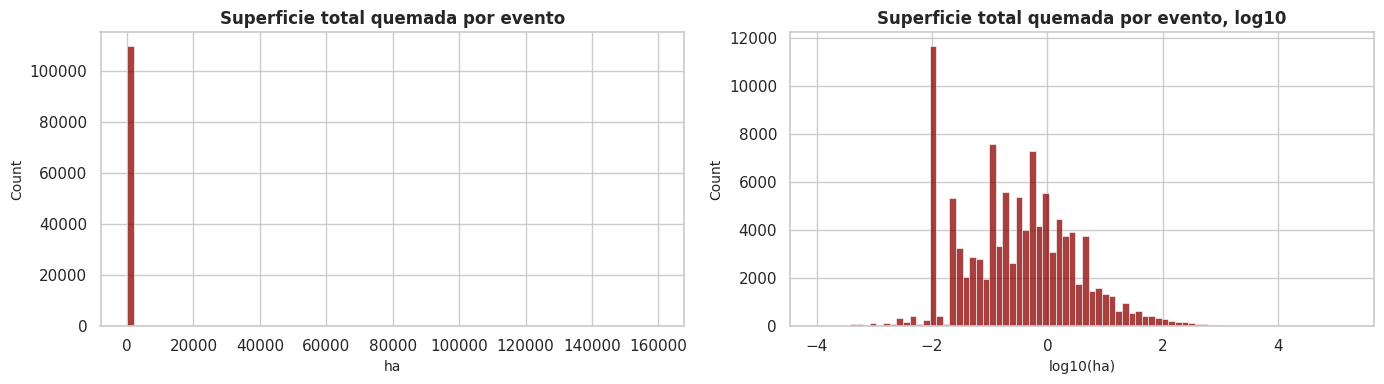

In [18]:
sup_pos = df.loc[df["superficie_total_ha"] > 0, "superficie_total_ha"]
surface_stats = sup_pos.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("superficie_total_ha")
display(surface_stats.style.format("{:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(sup_pos, bins=80, ax=axes[0], color="darkred")
axes[0].set_title("Superficie total quemada por evento")
axes[0].set_xlabel("ha")
sns.histplot(np.log10(sup_pos), bins=80, ax=axes[1], color="darkred")
axes[1].set_title("Superficie total quemada por evento, log10")
axes[1].set_xlabel("log10(ha)")
plt.tight_layout()

### Ajuste power law no acumulativo

Se estima una distribución no acumulativa de superficie quemada usando bins logarítmicos. El ajuste usa la cola de la distribución (`A >= p90`) y asume:

`p(A) ∝ A^{-β}`

donde `A` es la magnitud del incendio en hectáreas y `β` es el negativo de la pendiente en escala log-log.

,métrica,valor
0,beta,1.878
1,pendiente log-log,-1.878
2,intercepto,-0.285
3,xmin ajuste (ha),5.500
4,bins usados,23.000
5,eventos en cola,"12,547.000"
6,R2 log-log,0.994


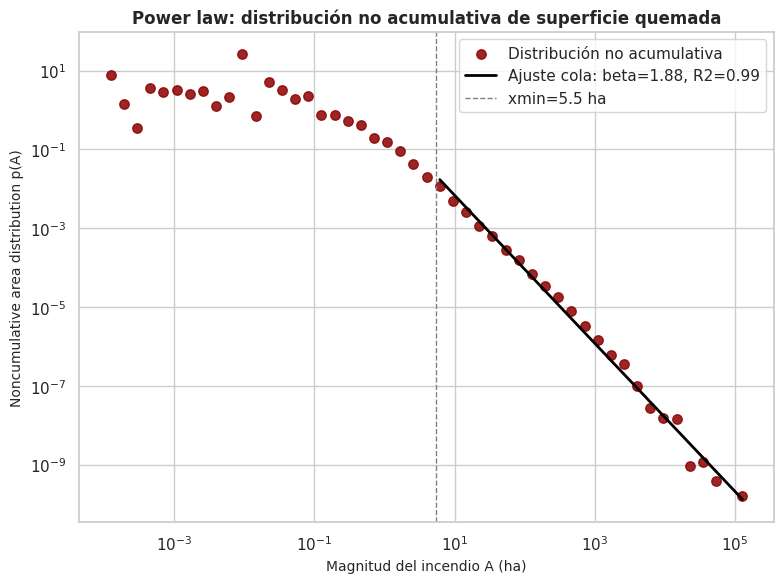

In [19]:
power_law_data = sup_pos.dropna().astype(float)
power_law_data = power_law_data[power_law_data > 0]

bins = np.logspace(
	np.log10(power_law_data.min()),
	np.log10(power_law_data.max()),
	50,
)
counts, edges = np.histogram(power_law_data, bins=bins)
bin_widths = np.diff(edges)
bin_centers = np.sqrt(edges[:-1] * edges[1:])
noncumulative_density = counts / (counts.sum() * bin_widths)

power_law_xmin = power_law_data.quantile(0.90)
fit_mask = (counts > 0) & np.isfinite(noncumulative_density) & (noncumulative_density > 0) & (bin_centers >= power_law_xmin)

if fit_mask.sum() < 3:
	power_law_xmin = power_law_data.quantile(0.75)
	fit_mask = (counts > 0) & np.isfinite(noncumulative_density) & (noncumulative_density > 0) & (bin_centers >= power_law_xmin)

log_x = np.log10(bin_centers[fit_mask])
log_y = np.log10(noncumulative_density[fit_mask])
slope, intercept = np.polyfit(log_x, log_y, 1)
power_law_beta = -slope
pred_log_y = intercept + slope * log_x
ss_res = np.sum((log_y - pred_log_y) ** 2)
ss_tot = np.sum((log_y - log_y.mean()) ** 2)
power_law_r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
power_law_fit_bins = int(fit_mask.sum())
power_law_fit_events = int(counts[fit_mask].sum())

fit_x = np.logspace(log_x.min(), log_x.max(), 100)
fit_y = 10 ** (intercept + slope * np.log10(fit_x))
plot_mask = (counts > 0) & np.isfinite(noncumulative_density) & (noncumulative_density > 0)

power_law_summary = pd.DataFrame(
	{
		"métrica": ["beta", "pendiente log-log", "intercepto", "xmin ajuste (ha)", "bins usados", "eventos en cola", "R2 log-log"],
		"valor": [
			power_law_beta,
			slope,
			intercept,
			power_law_xmin,
			power_law_fit_bins,
			power_law_fit_events,
			power_law_r2,
		],
	}
)
display(power_law_summary.style.format({"valor": "{:,.3f}"}))

plt.figure(figsize=(8, 6))
plt.scatter(
	bin_centers[plot_mask],
	noncumulative_density[plot_mask],
	s=46,
	alpha=0.85,
	color="darkred",
	label="Distribución no acumulativa",
)
plt.plot(
	fit_x,
	fit_y,
	color="black",
	linewidth=2,
	label=f"Ajuste cola: beta={power_law_beta:.2f}, R2={power_law_r2:.2f}",
)
plt.axvline(power_law_xmin, color="gray", linestyle="--", linewidth=1, label=f"xmin={power_law_xmin:.1f} ha")
plt.xscale("log")
plt.yscale("log")
plt.title("Power law: distribución no acumulativa de superficie quemada")
plt.xlabel("Magnitud del incendio A (ha)")
plt.ylabel("Noncumulative area distribution p(A)")
plt.legend()
plt.tight_layout()

### Betas por escenario

Se repite el ajuste no acumulativo por `escenario`. Para mantener estabilidad numérica, cada escenario intenta ajustar la cola `p90`; si quedan menos de 5 bins positivos, se relaja a `p75` y luego a `p50`. Los escenarios con pocos eventos deben interpretarse con cautela, aunque el ajuste entregue un `R2` alto.

,escenario,beta,r2_log_log,xmin_ha,cola_usada,bins_usados,eventos_en_cola,eventos_positivos,soporte
0,IFASP,1.241,0.915,6.18,p75,5,19,68,bajo
1,IFSu,1.329,0.989,0.50,p50,5,21,47,bajo
2,IFCSo,1.527,0.871,36.47,p90,7,23,244,medio
3,IFor-PI,1.550,0.994,26.00,p90,21,322,"3,224",alto
4,IFIUr-Fo,1.640,0.991,5.00,p90,23,797,"7,265",alto
5,IFIns,1.652,0.943,5.00,p50,6,34,91,bajo
6,IFor-Vn,1.771,0.994,9.50,p90,21,"1,237","12,333",alto
7,No definido,1.849,0.992,5.00,p90,21,"9,480","86,221",alto
8,IFCo,2.200,0.914,71.40,p90,6,26,284,medio


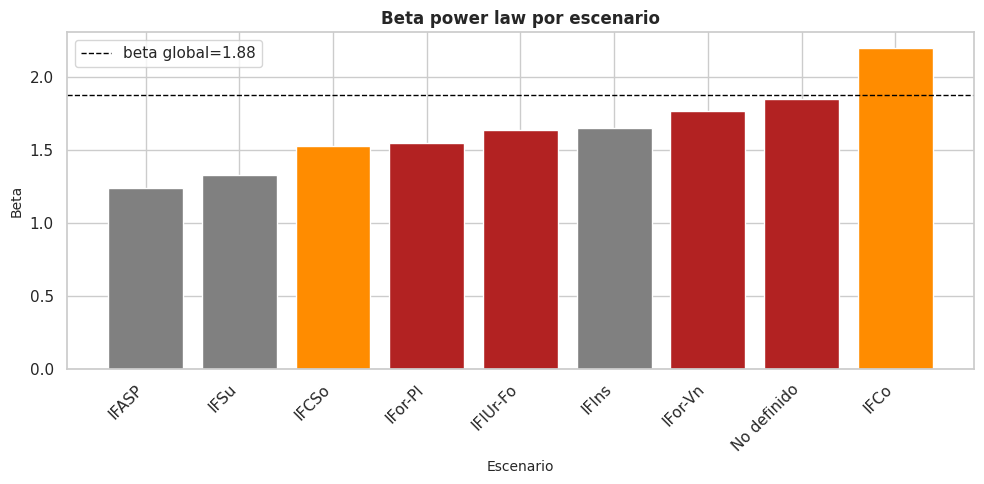

In [20]:
def fit_noncumulative_power_law(values, tail_quantile=0.90, min_fit_bins=5):
	data = pd.to_numeric(values, errors="coerce").dropna().astype(float)
	data = data[data > 0]
	if len(data) < 30 or data.nunique() < 3:
		return None

	bins_count = int(np.clip(np.sqrt(len(data)) * 2, 12, 50))
	bins = np.logspace(np.log10(data.min()), np.log10(data.max()), bins_count)
	counts, edges = np.histogram(data, bins=bins)
	bin_widths = np.diff(edges)
	bin_centers = np.sqrt(edges[:-1] * edges[1:])
	noncumulative_density = counts / (counts.sum() * bin_widths)

	fit_quantile = tail_quantile
	fit_mask = (counts > 0) & np.isfinite(noncumulative_density) & (noncumulative_density > 0) & (bin_centers >= data.quantile(fit_quantile))
	if fit_mask.sum() < min_fit_bins:
		fit_quantile = 0.75
		fit_mask = (counts > 0) & np.isfinite(noncumulative_density) & (noncumulative_density > 0) & (bin_centers >= data.quantile(fit_quantile))
	if fit_mask.sum() < min_fit_bins:
		fit_quantile = 0.50
		fit_mask = (counts > 0) & np.isfinite(noncumulative_density) & (noncumulative_density > 0) & (bin_centers >= data.quantile(fit_quantile))
	if fit_mask.sum() < 3:
		return None

	log_x = np.log10(bin_centers[fit_mask])
	log_y = np.log10(noncumulative_density[fit_mask])
	slope, intercept = np.polyfit(log_x, log_y, 1)
	pred_log_y = intercept + slope * log_x
	ss_res = np.sum((log_y - pred_log_y) ** 2)
	ss_tot = np.sum((log_y - log_y.mean()) ** 2)

	return {
		"eventos_positivos": int(len(data)),
		"beta": float(-slope),
		"pendiente": float(slope),
		"intercepto": float(intercept),
		"xmin_ha": float(data.quantile(fit_quantile)),
		"cola_usada": f"p{int(fit_quantile * 100)}",
		"bins_usados": int(fit_mask.sum()),
		"eventos_en_cola": int(counts[fit_mask].sum()),
		"r2_log_log": float(1 - ss_res / ss_tot) if ss_tot else np.nan,
	}

scenario_rows = []
for escenario, group in df.groupby("escenario"):
	fit = fit_noncumulative_power_law(group["superficie_total_ha"])
	if fit is None:
		scenario_rows.append(
			{
				"escenario": escenario,
				"eventos_positivos": int((group["superficie_total_ha"] > 0).sum()),
				"beta": np.nan,
				"pendiente": np.nan,
				"intercepto": np.nan,
				"xmin_ha": np.nan,
				"cola_usada": "insuficiente",
				"bins_usados": 0,
				"eventos_en_cola": 0,
				"r2_log_log": np.nan,
			}
		)
		continue
	fit["escenario"] = escenario
	scenario_rows.append(fit)

scenario_power_law = pd.DataFrame(scenario_rows).sort_values("beta").reset_index(drop=True)
scenario_power_law["soporte"] = np.where(
	scenario_power_law["eventos_positivos"] >= 1_000,
	"alto",
	np.where(scenario_power_law["eventos_positivos"] >= 200, "medio", "bajo"),
)
scenario_power_law_valid = scenario_power_law.dropna(subset=["beta"]).copy()

display(
	scenario_power_law[
		[
			"escenario",
			"beta",
			"r2_log_log",
			"xmin_ha",
			"cola_usada",
			"bins_usados",
			"eventos_en_cola",
			"eventos_positivos",
			"soporte",
		]
	].style.format(
		{
			"beta": "{:.3f}",
			"r2_log_log": "{:.3f}",
			"xmin_ha": "{:,.2f}",
			"bins_usados": "{:,}",
			"eventos_en_cola": "{:,}",
			"eventos_positivos": "{:,}",
		}
	)
)

plt.figure(figsize=(10, 5))
bar_colors = scenario_power_law_valid["soporte"].map({"alto": "firebrick", "medio": "darkorange", "bajo": "gray"})
plt.bar(scenario_power_law_valid["escenario"], scenario_power_law_valid["beta"], color=bar_colors)
plt.axhline(power_law_beta, color="black", linestyle="--", linewidth=1, label=f"beta global={power_law_beta:.2f}")
plt.title("Beta power law por escenario")
plt.xlabel("Escenario")
plt.ylabel("Beta")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

,superficie_total_ha,pct_superficie
superficie_quemada_matorral_ha,"357,666.9",22.9%
superficie_quemada_pastizal_ha,"266,412.1",17.0%
superficie_quemada_arbolado_ha,"246,530.7",15.8%
superficie_quemada_pino_c_ha,"199,979.7",12.8%
superficie_quemada_eucalipto_ha,"145,474.9",9.3%
superficie_quemada_pino_a_ha,"112,891.9",7.2%
superficie_quemada_pino_b_ha,"89,069.0",5.7%
superficie_quemada_desechos_ha,"83,536.0",5.3%
superficie_quemada_agricola_ha,"53,332.8",3.4%
superficie_quemada_otras_plantas_ha,"7,975.9",0.5%


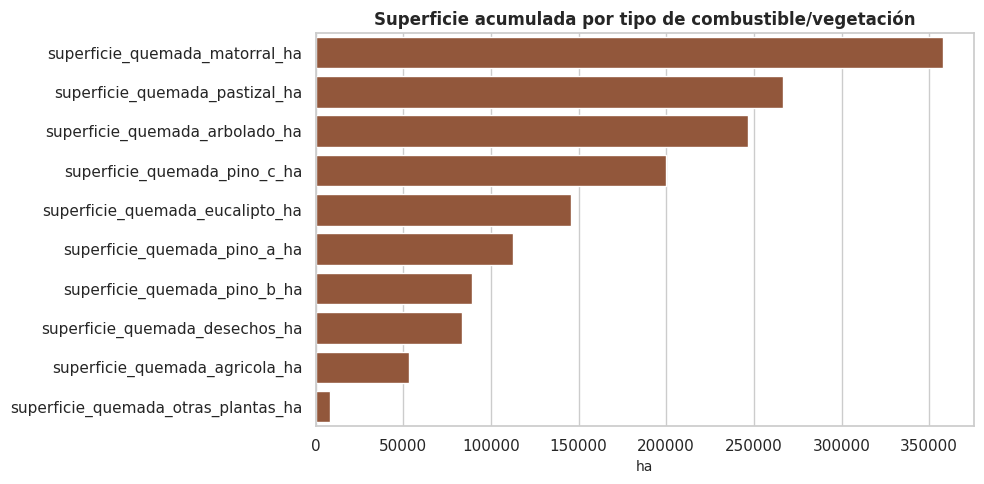

In [21]:
veg_totals = (
	df[VEG_COLS]
	.apply(pd.to_numeric, errors="coerce")
	.sum()
	.sort_values(ascending=False)
	.rename("superficie_total_ha")
	.to_frame()
)
veg_totals["pct_superficie"] = veg_totals["superficie_total_ha"] / veg_totals["superficie_total_ha"].sum()
display(veg_totals.style.format({"superficie_total_ha": "{:,.1f}", "pct_superficie": "{:.1%}"}))

plt.figure(figsize=(10, 5))
sns.barplot(data=veg_totals.reset_index(), x="superficie_total_ha", y="index", color="sienna")
plt.title("Superficie acumulada por tipo de combustible/vegetación")
plt.xlabel("ha")
plt.ylabel("")
plt.tight_layout()

In [22]:
top_fires = (
	df.sort_values("superficie_total_ha", ascending=False)
	[["temporada", "fecha_hora_inicio", "region", "provincia", "comuna", "nombre", "alerta", "escenario", "causa", "superficie_total_ha", "duracion_minutos"]]
	.head(20)
)
display(top_fires.style.format({"superficie_total_ha": "{:,.1f}", "duracion_minutos": "{:,.0f}"}))

,temporada,fecha_hora_inicio,region,provincia,comuna,nombre,alerta,escenario,causa,superficie_total_ha,duracion_minutos
85090,2016-2017,2017-01-20 22:01:00,Maule,Cauquenes,Cauquenes,LAS MÁQUINAS,Alerta roja,IFor-PI,Incendios de causa desconocida,"159,812.6",776
84536,2016-2017,2017-01-17 16:35:00,O'Higgins,Colchagua,Pumanque,NILAHUE BARAHONA,Alerta roja,IFor-PI,Accidentes eléctricos,"46,490.0",85
85059,2016-2017,2017-01-14 23:00:00,Maule,Curicó,Vichuquén,LAS CARDILLAS,Alerta roja,IFor-PI,Incendios intencionales,"37,308.1",628
86782,2016-2017,2017-01-20 22:33:00,Biobío,Concepción,Florida,SAN ANTONIO,Alerta roja,IFor-Vn,Incendios intencionales,"30,391.1","1,243"
54731,2011-2012,2011-12-30 02:37:00,Biobío,Concepción,Florida,PICHIQUEIME,Sin alerta,No definido,Incendios intencionales,"24,895.7",855
56121,2011-2012,2011-12-27 18:47:00,Magallanes,Ultima Esperanza,Torres del Paine,RIO OLGUIN,Sin alerta,No definido,Tránsito de personasvehículos o aeronaves,"17,606.3",238
19381,2004-2005,2005-02-17 12:55:00,Magallanes,Ultima Esperanza,Torres del Paine,LAGUNA AZUL,Sin alerta,No definido,No definida,"15,470.0","-1,000,000"
86849,2016-2017,2017-01-25 15:20:00,Biobío,Concepción,Concepción,CASERIO CHAIMAVIDA,Sin alerta,IFor-PI,Incendios intencionales,"15,204.7","1,434"
101158,2018-2019,2019-02-04 19:40:00,Aysén,Capitán Prat,Cochrane,COLONIA SUR,Alerta roja,IFor-Vn,Quema de desechos,"15,145.0",875
103140,2019-2020,2020-02-09 16:26:00,Maule,Curicó,Molina,AGUA FRIA,Alerta roja,IFor-PI,Incendios intencionales,"14,987.9",50


## 9. Duración

,duracion_minutos
count,"108,442.00"
mean,289.05
std,361.38
min,1.00
50%,132.00
75%,302.00
90%,984.00
95%,"1,220.00"
99%,"1,392.00"
max,"1,439.00"


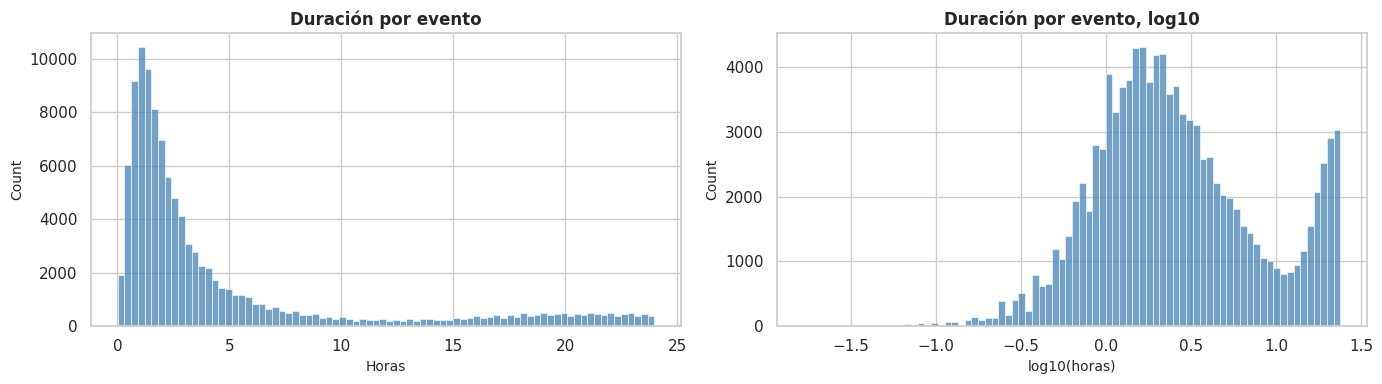

In [23]:
duration_pos = df.loc[df["duracion_minutos"] > 0, "duracion_minutos"]
duration_stats = duration_pos.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("duracion_minutos")
display(duration_stats.style.format("{:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(duration_pos / 60, bins=80, ax=axes[0], color="steelblue")
axes[0].set_title("Duración por evento")
axes[0].set_xlabel("Horas")
sns.histplot(np.log10(duration_pos / 60), bins=80, ax=axes[1], color="steelblue")
axes[1].set_title("Duración por evento, log10")
axes[1].set_xlabel("log10(horas)")
plt.tight_layout()

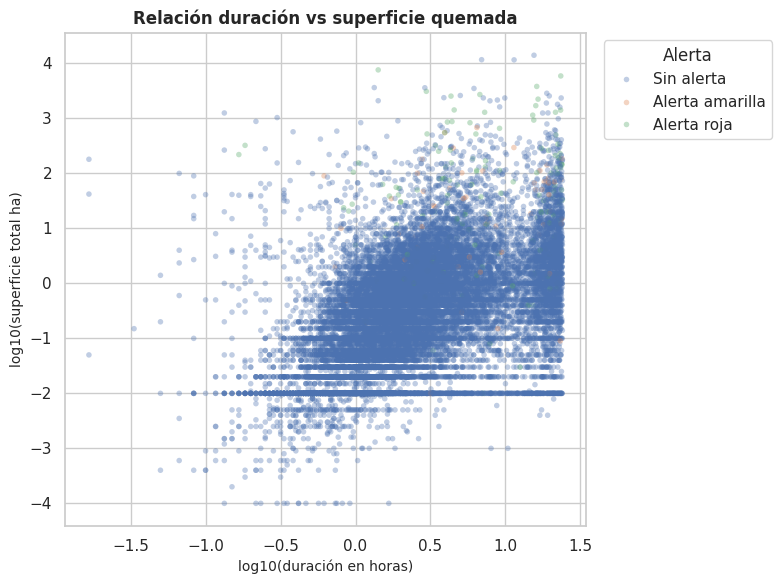

In [24]:
rel = df[(df["duracion_horas"] > 0) & (df["superficie_total_ha"] > 0)].copy()
rel_sample = rel.sample(min(20_000, len(rel)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
	data=rel_sample,
	x=np.log10(rel_sample["duracion_horas"]),
	y=np.log10(rel_sample["superficie_total_ha"]),
	hue="alerta",
	alpha=0.35,
	s=16,
	linewidth=0,
)
plt.title("Relación duración vs superficie quemada")
plt.xlabel("log10(duración en horas)")
plt.ylabel("log10(superficie total ha)")
plt.legend(title="Alerta", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 10. Conclusiones

In [25]:
top_season_events = season_summary["eventos"].idxmax()
top_season_surface = season_summary["superficie_total_ha"].idxmax()
top_region_events = region_summary["eventos"].idxmax()
top_region_surface = region_summary["superficie_total_ha"].idxmax()
top_commune = commune_summary["eventos"].idxmax()
top_scenario = scenario_summary["eventos"].idxmax()
top_alert = alert_summary["eventos"].idxmax()
top_cause = cause_summary["eventos"].idxmax()
summer_share = df["mes"].isin([11, 12, 1, 2, 3]).mean()
large_fire_threshold = df["superficie_total_ha"].quantile(0.99)
large_fire_share = df.loc[df["superficie_total_ha"] >= large_fire_threshold, "superficie_total_ha"].sum() / df["superficie_total_ha"].sum()
utc_missing = int(df["fecha_hora_inicio_utc"].isna().sum())
bbox_out = int((~chile_bbox & lat.notna() & lon.notna()).sum())

conclusions = f'''
- Cobertura: {fmt_int(len(df))} incendios entre {df['temporada'].min()} y {df['temporada'].max()}, con {fmt_ha(df['superficie_total_ha'].sum())} ha quemadas acumuladas.
- La temporada con más eventos es **{top_season_events}** ({fmt_int(season_summary.loc[top_season_events, 'eventos'])} registros); la de mayor superficie quemada es **{top_season_surface}** ({fmt_ha(season_summary.loc[top_season_surface, 'superficie_total_ha'])} ha).
- La estacionalidad es marcada: {pct(summer_share)} de los eventos ocurre entre noviembre y marzo.
- Territorialmente, **{top_region_events}** concentra más eventos ({fmt_int(region_summary.loc[top_region_events, 'eventos'])}); **{top_region_surface}** concentra más superficie quemada ({fmt_ha(region_summary.loc[top_region_surface, 'superficie_total_ha'])} ha). La comuna con más registros es **{top_commune[2]}** ({top_commune[0]}), con {fmt_int(commune_summary.loc[top_commune, 'eventos'])} eventos.
- La alerta dominante es **{top_alert}** ({pct(alert_summary.loc[top_alert, 'pct_eventos'])} de los eventos). El escenario dominante es **{top_scenario}** ({pct(scenario_summary.loc[top_scenario, 'pct_eventos'])}).
- La causa más frecuente es **{top_cause}** ({fmt_int(cause_summary.loc[top_cause, 'eventos'])} eventos), pero conviene revisar también superficie total por causa porque frecuencia e impacto no ordenan igual.
- La superficie quemada está fuertemente sesgada: mediana {fmt_ha(df['superficie_total_ha'].median())} ha, percentil 95 {fmt_ha(df['superficie_total_ha'].quantile(0.95))} ha y máximo {fmt_ha(df['superficie_total_ha'].max())} ha. El 1% superior de eventos concentra {pct(large_fire_share)} de la superficie total.
- En la distribución no acumulativa de superficie quemada, el ajuste power law de la cola (`A >= p90`) estima **beta = {power_law_beta:.2f}** con R2 log-log de {power_law_r2:.2f}.
- Los beta por escenario van desde **{scenario_power_law_valid.iloc[0]['escenario']} = {scenario_power_law_valid.iloc[0]['beta']:.2f}** hasta **{scenario_power_law_valid.iloc[-1]['escenario']} = {scenario_power_law_valid.iloc[-1]['beta']:.2f}**; los escenarios de soporte bajo deben leerse como indicativos.
- Calidad de datos: no hay coordenadas nulas; {fmt_int(bbox_out)} registros caen fuera del bbox continental amplio y deben tratarse como casos especiales/insulares antes de descartarlos. Hay {fmt_int(utc_missing)} timestamps UTC derivados nulos por ambigüedad horaria.
'''
display(Markdown(conclusions))


- Cobertura: 109.947 incendios entre 2002-2003 y 2019-2020, con 1.562.870,0 ha quemadas acumuladas.
- La temporada con más eventos es **2019-2020** (8.125 registros); la de mayor superficie quemada es **2016-2017** (570.158,9 ha).
- La estacionalidad es marcada: 89,2% de los eventos ocurre entre noviembre y marzo.
- Territorialmente, **Biobío** concentra más eventos (45.720); **Maule** concentra más superficie quemada (386.081,4 ha). La comuna con más registros es **Curanilahue** (Biobío), con 4.045 eventos.
- La alerta dominante es **Sin alerta** (99,0% de los eventos). El escenario dominante es **No definido** (78,6%).
- La causa más frecuente es **Incendios intencionales** (36.117 eventos), pero conviene revisar también superficie total por causa porque frecuencia e impacto no ordenan igual.
- La superficie quemada está fuertemente sesgada: mediana 0,3 ha, percentil 95 15,5 ha y máximo 159.812,6 ha. El 1% superior de eventos concentra 78,7% de la superficie total.
- En la distribución no acumulativa de superficie quemada, el ajuste power law de la cola (`A >= p90`) estima **beta = 1.88** con R2 log-log de 0.99.
- Los beta por escenario van desde **IFASP = 1.24** hasta **IFCo = 2.20**; los escenarios de soporte bajo deben leerse como indicativos.
- Calidad de datos: no hay coordenadas nulas; 209 registros caen fuera del bbox continental amplio y deben tratarse como casos especiales/insulares antes de descartarlos. Hay 6 timestamps UTC derivados nulos por ambigüedad horaria.
